In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from pathlib import Path
df = pd.read_csv(csv_path := Path(r"C:\Users\user\Desktop\div\data\files\housing.csv"))
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# df.plot('longitude', 'latitude', kind='scatter')

import seaborn as sns

In [5]:
sns.set()

<Axes: xlabel='longitude', ylabel='latitude'>

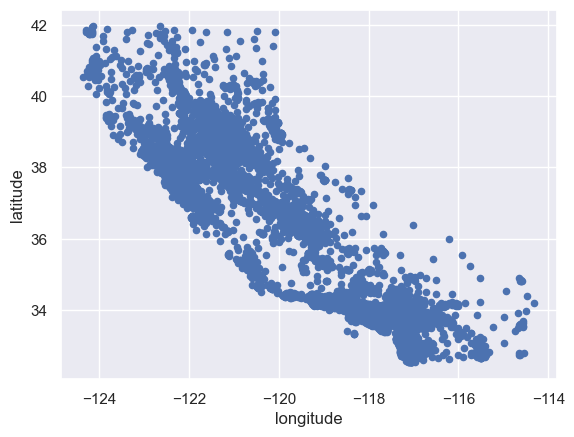

In [6]:
df.plot('longitude', 'latitude', kind='scatter')

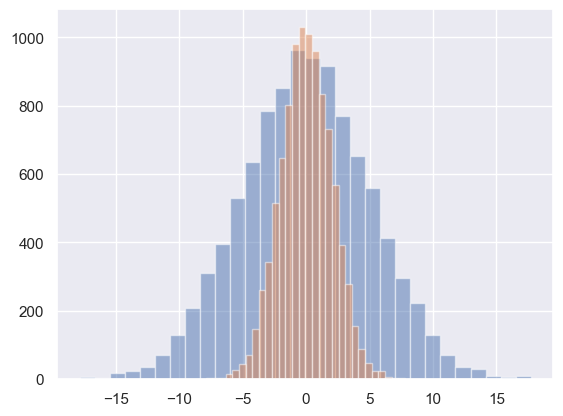

In [7]:
# x =np.random.normal(0, 2, 100)
# y =np.random.normal(0, 5, 100)

data = np.random.multivariate_normal(
	[0,0],
	[
		[4,5],
		[5,25],
	],
	size=10000
)

for i in range(1,-1,-1):
	plt.hist(data[:,i], alpha=0.5, bins=30)

plt.show()

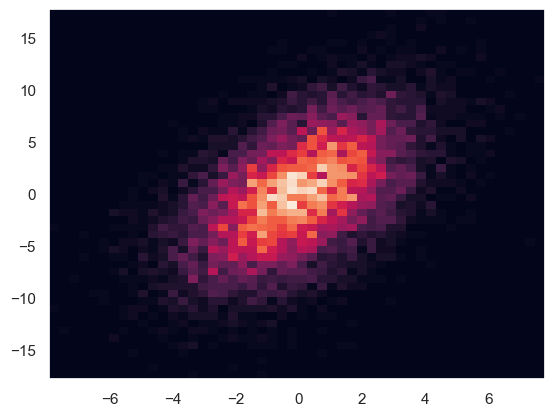

In [8]:
plt.hist2d(data[:, 0], data[:, 1], bins=50)
plt.show()

In [9]:
df = pd.DataFrame(data, columns=['x', 'y'])
df

,x,y
0,0.840880,2.026687
1,0.415139,5.529932
2,1.920995,-6.137158
3,3.986415,8.001792
4,-3.313581,-4.104925
...,...,...
9995,0.725869,-9.099050
9996,-3.543518,-0.234186
9997,-5.663412,-4.853169
9998,1.758589,-4.506734


<Axes: xlabel='x', ylabel='y'>

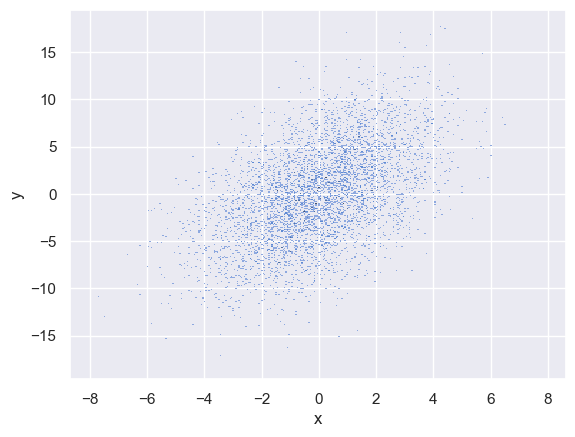

In [10]:
sns.histplot(
	df,
	x='x',
	y='y',
	# bins=50,
	binwidth=0.05
	)

In [11]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
df.groupby('species').mean(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


<Axes: xlabel='petal_length', ylabel='petal_width'>

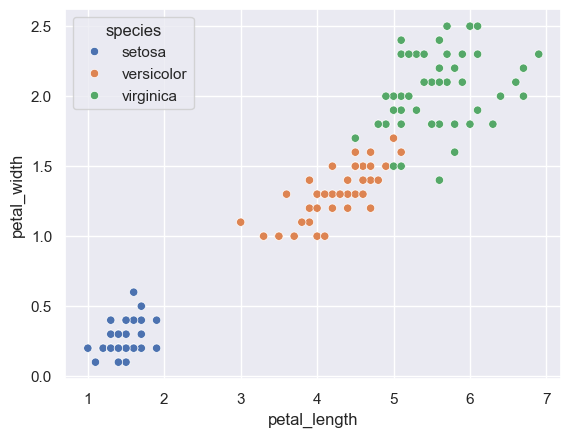

In [13]:
sns.scatterplot(
	df,
	x='petal_length',
	y='petal_width',
	hue='species'
	)

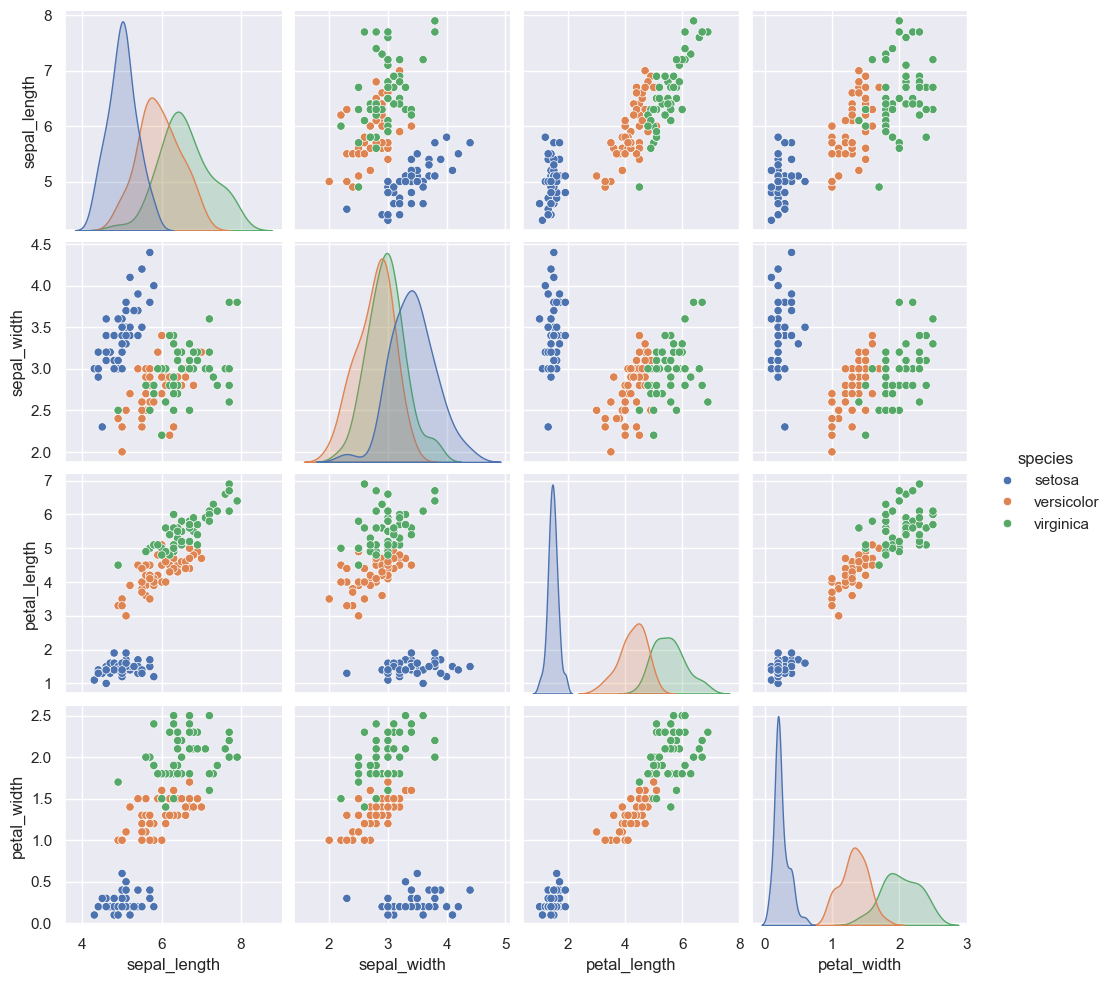

In [14]:
sns.pairplot(df, hue='species')

In [15]:
df2 = sns.load_dataset('tips')
df2.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [16]:
df2['tip_pct'] = df2['tip'] / df2['total_bill'] * 100
df2['tip_pct'] = df2['tip_pct'].round(2)
df2.head(2)

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05


In [17]:
df2.groupby(['sex', 'time'])['tip_pct'].mean()

sex     time  
Male    Lunch     16.607576
        Dinner    15.540403
Female  Lunch     16.227143
        Dinner    16.931731
Name: tip_pct, dtype: float64

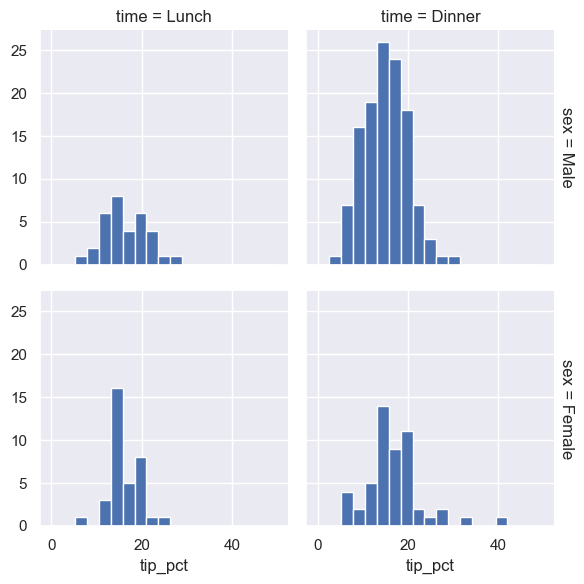

In [18]:
grid = sns.FacetGrid(df2, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0,50,20))

In [59]:
mask = df2['sex'] == 'Male'
df2.loc[mask, 'tip'].quantile(0.75)

np.float64(3.76)

In [ ]:
# inter quartile range
iqr = df2.loc[mask, 'tip'].quantile(0.75) - df2.loc[mask, 'tip'].quantile(0.25)
iqr

np.float64(1.7599999999999998)

In [63]:
df2.loc[mask, 'tip'].quantile(0.75) + 1.5 * iqr

np.float64(6.3999999999999995)

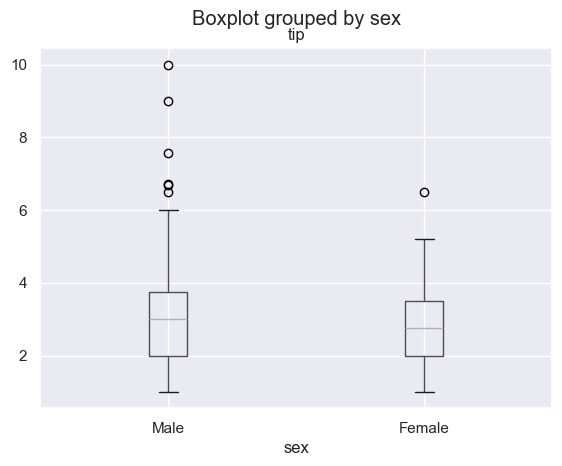

In [19]:
df2.boxplot(column='tip', by='sex');

In [20]:
df2

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.39
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.36
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.82
242,17.82,1.75,Male,No,Sat,Dinner,2,9.82


In [27]:
yashlar = np.random.randint(low=18, high=26, size=20)

# mean
# yashlar.sum() / len(yashlar)
print(yashlar.mean())

# median
# uz = len(yashlar)
# sorted(yashlar)[uz//2]
print(np.median(yashlar))

# mode
# np.unique_counts(yashlar)
pd.Series(yashlar).mode().loc[0]

22.15
22.5


np.int32(25)

In [38]:
yashlar2 = np.concat([yashlar, [60]])
yashlar2

array([25, 18, 20, 25, 19, 25, 23, 21, 18, 24, 25, 22, 23, 21, 21, 24, 23,
       21, 25, 20, 60])

In [39]:
yashlar.mean(), yashlar2.mean()

(np.float64(22.15), np.float64(23.952380952380953))

In [40]:
np.median(yashlar), np.median(yashlar2)

(np.float64(22.5), np.float64(23.0))

In [42]:
yashlar.sort()
yashlar

array([18, 18, 19, 20, 20, 21, 21, 21, 21, 22, 23, 23, 23, 24, 24, 25, 25,
       25, 25, 25], dtype=int32)

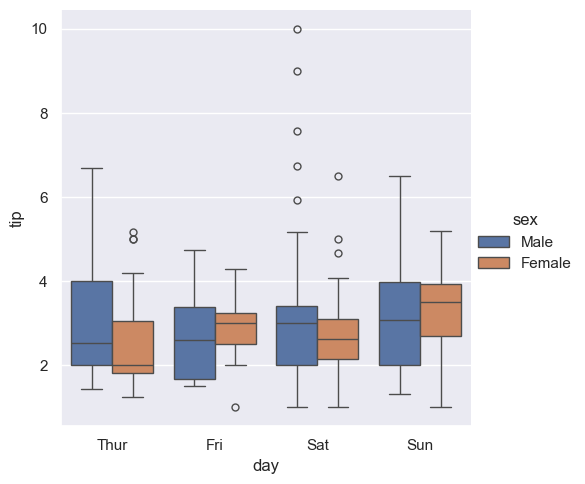

In [71]:
sns.catplot(
	df2, 
	x='day', 
	y='tip',
	hue='sex',
	kind='box'
)

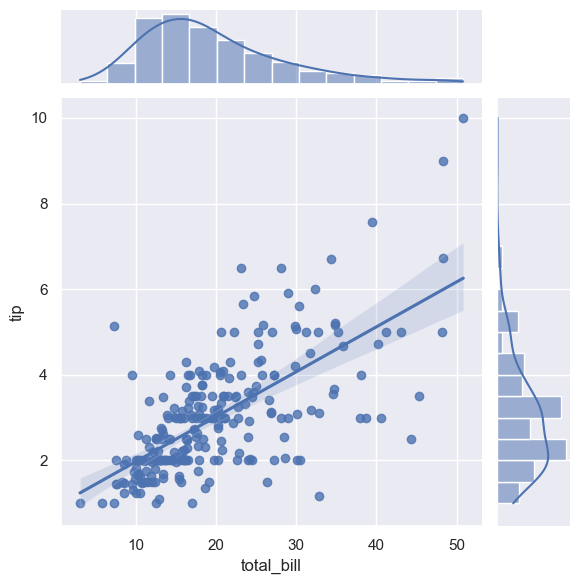

In [74]:
sns.jointplot(df2, x='total_bill', y='tip', kind='reg');